In [17]:
from pathlib import Path
import random
from pprint import pprint
import logging
from IPython.display import display, Markdown
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

In [3]:
Path.cwd()

WindowsPath('c:/Projects/KINECTRICS/Anomaly-Detection/notebooks')

## Initial configurations

In [104]:
#-------------------------------------------------------------------------------
# Paths
#-------------------------------------------------------------------------------

DATA_DIR = Path("../data/data_jpg_crop_512x512").resolve()
print(DATA_DIR, '\n')
CLEAN_DIRS  = [DATA_DIR / 'clean_v1', DATA_DIR / 'clean_v2']
print(*CLEAN_DIRS)

#-------------------------------------------------------------------------------
# Constants
#-------------------------------------------------------------------------------

SEED = 42
IMG_SIZE = (512, 512)
CORRUPTION_FACTOR = 0.5 # Higher → more corruption. 0.5 means the noise will have a stddev of 0.5, which is quite high for pixel values in [0,1]. Adjust as needed.
BATCH_SIZE = 8
EPOCHS = 40
VAL_SPLIT = 0.15
AUTOTUNE = tf.data.AUTOTUNE # -1

VALID_EXTS = {".jpg", ".jpeg"}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

C:\Projects\KINECTRICS\Anomaly-Detection\data\data_jpg_crop_512x512 

C:\Projects\KINECTRICS\Anomaly-Detection\data\data_jpg_crop_512x512\clean_v1 C:\Projects\KINECTRICS\Anomaly-Detection\data\data_jpg_crop_512x512\clean_v2


---
# Data Preparation
---

### List paths:

In [14]:
def list_files(directory: Path) -> list[Path]:
    """ Returns the list of paths of all the images in the given directory and subdirectories. """
    files = []
    for root, dirs, filenames in os.walk(directory):
        for fl in filenames:
            if Path(fl).suffix.lower() not in VALID_EXTS: # skip non-image files
                continue
            files.append(Path(root) / fl)
    files.sort()
    return files

In [20]:
data_images = [*list_files(CLEAN_DIRS[0]), *list_files(CLEAN_DIRS[1])]
print(f'{len(data_images)} clean images where found in {CLEAN_DIRS[0]} and {CLEAN_DIRS[1]}')

230 clean images where found in C:\Projects\KINECTRICS\Anomaly-Detection\data\data_jpg_crop_512x512\clean_v1 and C:\Projects\KINECTRICS\Anomaly-Detection\data\data_jpg_crop_512x512\clean_v2


In [ ]:
random.shuffle(data_images)
n_val = int(len(data_images) * VAL_SPLIT)

train_paths = data_images[n_val:]
val_paths = data_images[:n_val]

print(f'{len(train_paths)} training images and {len(val_paths)} validation images')

196 training images and 34 validation images


### Load Data:
`tf.oi` is the tensorflow module for input/output operations. Is the module of tensorflow for reading, writing, parsing and transforming data:

In [ ]:
def load_image_tf(path: tf.Tensor) -> tf.Tensor:
    ''' Loads an image from the given path and preprocesses it for training. Only supports JPG images.
    Returns a tensor of shape (H, W, 3) and dtype float32 with pixel values in [0,1]. '''
    image_bytes = tf.io.read_file(path) # read the image file as a bytes string
    image = tf.image.decode_jpeg(image_bytes, channels=3) # decode the bytes string into a tensor of shape (H, W, 3) and dtype uint8 
    image = tf.image.convert_image_dtype(image, tf.float32)  # Rescale to [0,1] (better for training)
    image = tf.image.resize(image, IMG_SIZE) # Since the image is already square, the resizing will not distort the image
    return image

In [33]:
load_image_tf(str(train_paths[0]))

<tf.Tensor: shape=(512, 512, 3), dtype=float32, numpy=
array([[[0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        ...,
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138]],

       [[0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        ...,
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138]],

       [[0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        ...,
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138]],

       ...,

       [[0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.7843138, 0.7843138],
        [0.7843138, 0.78431

### Add noise to the images:

In [100]:
def _add_mild_corruption(image: tf.Tensor) -> tf.Tensor:
    ''' Adds mild corruption to the given image tensor. Returns a corrupted image tensor of the same shape and dtype as the input, with pixel values in [0,1]. '''
    x = image
    # Mild Gaussian noise
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=CORRUPTION_FACTOR, dtype=tf.float32)
    x = x + noise # Add noise. Can push pixels outside [0,1].
    x = tf.clip_by_value(x, 0.0, 1.0) # Ensure pixel values are still in [0,1]. If p > 1 → 1, if p < 0 → 0.

    # Mild brightness variation
    x = tf.image.random_brightness(x, max_delta=0.05)
    x = tf.clip_by_value(x, 0.0, 1.0)

    # Mild contrast variation
    x = tf.image.random_contrast(x, lower=0.95, upper=1.05)
    x = tf.clip_by_value(x, 0.0, 1.0)

    return x

In [101]:
def corrupt_and_clean_from_path(path: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    ''' Loads the image at the given path, creates a mildly corrupted version of it, and returns both the corrupted and clean images as tensors. '''
    clean = load_image_tf(path)
    corrupted = _add_mild_corruption(clean)
    return corrupted, clean

### Lazy loading and on-the-fly corruption of the images during training:
`tf.data.Dataset` is the main class of the module. It is not a data container but a **data transformation pipeline**. The object `Dataset` is an iterable, processes elements lazily (on-the-fly) as they are requested:
- `map` transforms each element of the dataset **on-the-fly.**
- `batch` groups elements into batches for efficient computation during training.
- `prefetch` optimizes the process. Allows the data pipeline to prepare the next batch while the current batch is being processed by the model, reducing idle time. 
    - e.g., CPU prepares data while GPU (or CPU) processes the current batch

Without `tf.data`:
- All the data is loaded in the RAM.
- Data pipelines are typically less efficient.
- No automatic parallelism or overlap between preprocessing and model execution.

<span style='color:yellow'> Note: </span> A `Dataset` behaves similarly to a Python **generator**, but supports parallelism, optimization, and complex transformations

In [113]:
# Create a dataset with the list of paths:
train_ds = tf.data.Dataset.from_tensor_slices([str(p) for p in train_paths])
# Shuffle the dataset (only the paths, not the images yet) to ensure random order at each epoch during training:
train_ds = train_ds.shuffle(buffer_size=len(train_paths), seed=SEED) 
# Apply corruption and loading in parallel to speed up the data pipeline:
train_ds = train_ds.map(corrupt_and_clean_from_path, num_parallel_calls=AUTOTUNE) # Each element of the dataset is now a tuple (corrupted_image, clean_image):
# Batch the dataset: 
train_ds = train_ds.batch(BATCH_SIZE)
# Prefetch to improve performance:
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices([str(p) for p in val_paths])
val_ds = val_ds.map(corrupt_and_clean_from_path, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
# TODO: wrap the above dataset creation in a function.

In [115]:
type(next(iter(val_ds))[0])

tensorflow.python.framework.ops.EagerTensor

In [118]:
def show_batch_examples(dataset: tf.data.Dataset, n: int = 3) -> None:
    batch_x, batch_y = next(iter(dataset))

    plt.figure(figsize=(12, 4 * n))
    for i in range(n):
        # Corrupted
        plt.subplot(n, 2, 2 * i + 1) # The 3rd argument is the index of the subplot. +1 means to plot always in the first column.
        plt.imshow(batch_x[i].numpy()) # Convert the tensor to a numpy array for plotting. The pixel values are still in [0,1], but plt.imshow interprets them correctly using the dtype and range. Rescales the data accordingly to [0,255].
        plt.title("Input corrupted")
        plt.axis("off")

        # Clean
        plt.subplot(n, 2, 2 * i + 2) # +2 means to plot always in the second column.
        plt.imshow(batch_y[i].numpy())
        plt.title("Target clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

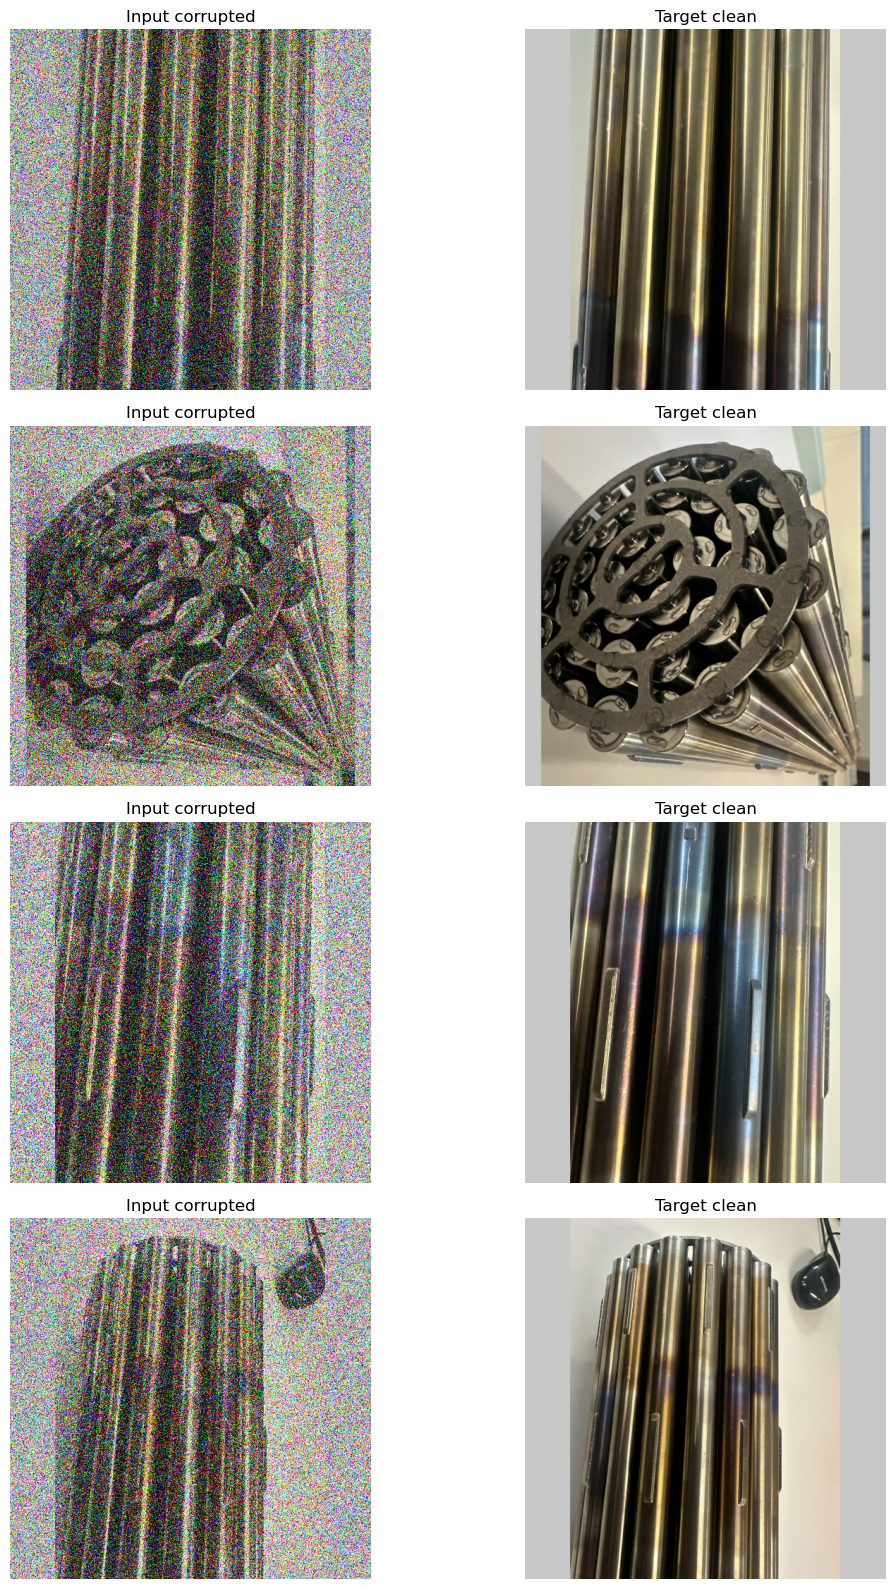

In [119]:
show_batch_examples(train_ds, n=4)

---
# Model Definition
---

### Encoder-decoder convolutional with U-net skip type:

In [123]:
def _conv_block(x: tf.Tensor, filters: int, kernel_size: int = 3) -> tf.Tensor:
    ''' A convolutional block consisting of two Conv2D layers, each followed by BatchNormalization and ReLU activation. Returns the output tensor after applying the block. '''
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

In [124]:
def build_unet_dae(input_shape: tuple[int, int, int] = (512, 512, 3)) -> keras.Model:
    ''' Builds a U-Net architecture for a denoising autoencoder. The model takes an input image of the specified shape and outputs a denoised image of the same shape. Returns the model. '''
    inputs = keras.Input(shape=input_shape)

    # Encoder
    c1 = _conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = _conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = _conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    c4 = _conv_block(p3, 256)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = _conv_block(p4, 512)

    # Decoder
    u4 = layers.UpSampling2D()(bn)
    u4 = layers.Concatenate()([u4, c4])
    c5 = _conv_block(u4, 256)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = _conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = _conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = _conv_block(u1, 32)

    outputs = layers.Conv2D(3, 1, activation="sigmoid", padding="same")(c8)

    model = keras.Model(inputs, outputs, name="unet_dae")
    return model

In [125]:
model = build_unet_dae(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mae",
    metrics=["mse"],
)

model.summary()

Model: "unet_dae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_4[0][0]  

 Total params: 7,858,499 (29.98 MB)

 Trainable params: 7,852,611 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [126]:
checkpoint_path = "best_unet_dae.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        verbose=1,
    ),
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)